<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=3><B>lecture 7 文本分析（2） (郑海超)</B></font></td></tr></table>

# 教学内容
* 词袋（文本量化表示方法之一）
* 信息检索:TF-IDF（这个是词袋的改进）
* 关键词提取:PageRank算法
* 课后学习安排

# 上周课后作业分享

# 课后阅读分享
- Chapter 6: Building a Portfolio of Projects that Shows Skill Progression

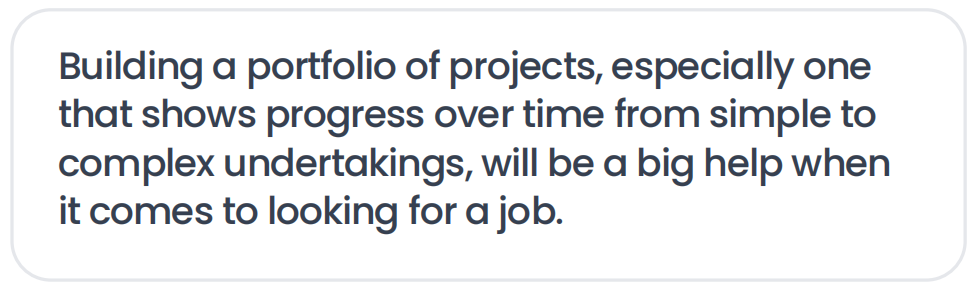

# 文本分析
- 切词
- 情感分析


- 信息检索
- 词袋（文本表示方法之一）
- 关键词提取
- 应用机器学习做文本分类和主题建模（这我们安排到机器学习环节）


- 应用大模型做文本分析（下周）

# 词袋（bag of words）

思考：如何表示（量化）一个文本？
- 评论中的关键情感词可以一定程度上代表一个评论
- 仅仅使用情感词频有什么不足

<img src="../img/bow.png" align='left' height="400" width="500"/>

## 编程构建词典并使用字典保存

### 构建语料

In [6]:
# Define a corpus of text documents
corpus = ['I like programing',
        'data anlaysis is very fun',
        'I like python, do you like it',  
        'I like data analysis',
          'financial data analysis is fun']

### 构建词表

In [7]:
from typing import Any

# Create an empty set to store the vocabulary
vocabulary = set[Any]()

# Loop over each document in the corpus
for doc in corpus:
    # Split the document into words and add them to the vocabulary
    words = doc.split()
    vocabulary.update(words)

### 构建bag_of_words

In [8]:
# Create an empty list to store the bag of words representations
bag_of_words = []

# Loop over each document in the corpus
for doc in corpus:
    # Create an empty dictionary to store the word counts for this document
    word_counts = {}
    # Split the document into words
    words = doc.split()
    # Loop over each word in the vocabulary
    for word in vocabulary:
        # If the word is in the document, add its count to the dictionary
        if word in words:
            word_counts[word] = words.count(word)
        # If the word is not in the document, add it to the dictionary with a count of 0
        else:
            word_counts[word] = 0
    # Add the word counts dictionary to the bag_of_words list
    bag_of_words.append(word_counts)

### 打印bag_of_words并做适当转换

In [9]:
# Print the bag of words representation of each document
for i, doc in enumerate(corpus):
    print(f"Document {i}:")
    print(bag_of_words[i])

Document 0:
{'fun': 0, 'financial': 0, 'very': 0, 'programing': 1, 'do': 0, 'anlaysis': 0, 'data': 0, 'python,': 0, 'like': 1, 'analysis': 0, 'is': 0, 'I': 1, 'it': 0, 'you': 0}
Document 1:
{'fun': 1, 'financial': 0, 'very': 1, 'programing': 0, 'do': 0, 'anlaysis': 1, 'data': 1, 'python,': 0, 'like': 0, 'analysis': 0, 'is': 1, 'I': 0, 'it': 0, 'you': 0}
Document 2:
{'fun': 0, 'financial': 0, 'very': 0, 'programing': 0, 'do': 1, 'anlaysis': 0, 'data': 0, 'python,': 1, 'like': 2, 'analysis': 0, 'is': 0, 'I': 1, 'it': 1, 'you': 1}
Document 3:
{'fun': 0, 'financial': 0, 'very': 0, 'programing': 0, 'do': 0, 'anlaysis': 0, 'data': 1, 'python,': 0, 'like': 1, 'analysis': 1, 'is': 0, 'I': 1, 'it': 0, 'you': 0}
Document 4:
{'fun': 1, 'financial': 1, 'very': 0, 'programing': 0, 'do': 0, 'anlaysis': 0, 'data': 1, 'python,': 0, 'like': 0, 'analysis': 1, 'is': 1, 'I': 0, 'it': 0, 'you': 0}


In [10]:
# 将bag of words转换为dataframe
import pandas as pd
bags = pd.DataFrame(bag_of_words)

In [ ]:
bags

## 使用CountVectorizer构建词袋

https://scikit-learn.org/1.7/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

### 准备中文训练数据

In [11]:
import jieba

In [12]:
sentence = "学习金融数据分析, 要做好课堂基础学习与课后作业"

In [ ]:
# 将上述这句话切词并用空格链接起来





In [13]:
def word_cut_chinese(corpus, word_separator):
    word_cut_results = list()
    for document in corpus:
        word_cut_results.append(word_separator.join(jieba.cut(document)))
    # 可再加一步去停用词
    return word_cut_results

In [14]:
WORD_SEPARATOR = ' ' # 切词
corpus = ['我第一次学习数据分析，真的有点慌真的好着急啊',
          '不要紧张,一切都会好起来的',
          '学习金融数据分析, 要做好课堂基础学习与课后作业']
train_data = word_cut_chinese(corpus, WORD_SEPARATOR)
train_data

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Nanzheng\AppData\Local\Temp\jieba.cache
Loading model cost 0.617 seconds.
Prefix dict has been built successfully.


['我 第一次 学习 数据分析 ， 真的 有点 慌 真的 好 着急 啊',
 '不要 紧张 , 一切 都 会 好 起来 的',
 '学习 金融 数据分析 ,   要 做好 课堂 基础 学习 与 课后 作业']

### 定义并拟合（fit）CountVectorizer对象

安装scikit-learn

In [1]:
!pip install scikit-learn

Looking in indexes: https://pypi.org/simple/


In [2]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# 定义count_vectorizer
count_vectorizer = CountVectorizer()

In [16]:
count_vectorizer.vocabulary_

{'第一次': 10,
 '学习': 5,
 '数据分析': 6,
 '真的': 8,
 '有点': 7,
 '着急': 9,
 '不要': 1,
 '紧张': 11,
 '一切': 0,
 '起来': 14,
 '金融': 15,
 '做好': 3,
 '课堂': 13,
 '基础': 4,
 '课后': 12,
 '作业': 2}

In [15]:
# 使用train_data拟合count_vectorizer
count_vectorizer.fit(train_data)






CountVectorizer()

In [17]:
count_vectorizer.vocabulary_

{'第一次': 10,
 '学习': 5,
 '数据分析': 6,
 '真的': 8,
 '有点': 7,
 '着急': 9,
 '不要': 1,
 '紧张': 11,
 '一切': 0,
 '起来': 14,
 '金融': 15,
 '做好': 3,
 '课堂': 13,
 '基础': 4,
 '课后': 12,
 '作业': 2}

### 将拟合后的CountVectorizer对象应用（transform）到数据集

**应用到原有的数据集**

In [ ]:
#应用拟合后的count_vectorizer对train_data做transform，形成词袋矩阵counts
counts = count_vectorizer.transform(train_data)


In [19]:
counts_array = counts.toarray()
print(counts_array)

[[0 0 0 0 0 1 1 1 2 1 1 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0]
 [0 0 1 1 1 2 1 0 0 0 0 0 1 1 0 1]]


In [20]:
type(counts_array)

numpy.ndarray

In [21]:
counts_array.shape

(3, 16)

上面两个步骤fit和transform可以合并在一起fit_transform，将train_data转换为一个词袋矩阵（文本的一种量化表示方法）

In [22]:
# 上面两个步骤fit和transform可以合并在一起fit_transform
X_counts = count_vectorizer.fit_transform(train_data) # fit和fit_transform不一样
# print(count_vectorizer.vocabulary_)
print(X_counts.toarray())

[[0 0 0 0 0 1 1 1 2 1 1 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0]
 [0 0 1 1 1 2 1 0 0 0 0 0 1 1 0 1]]


In [23]:
X_counts.shape

(3, 16)

**应用到新的（测试）数据集**

In [24]:
test_data = ["今天 继续 学习 金融 数据分析 非常 开心"]

In [26]:
# 使用拟合好的count_vectorizer对test_data，做transform，生成测试集的词袋矩阵 count_matrix
count_matrix = count_vectorizer.transform(test_data)




In [27]:
print(count_matrix.todense())

[[0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1]]


In [28]:
count_matrix.shape

(1, 16)

**观察思考：应用到train data和 test data的结果有什么相同之处和不同之处，二者的联系是什么**

## 考虑stop_words做词袋

Stop words are words like “and”, “the”, “him”, which are presumed to be uninformative in representing the content of a text, and which may be removed to avoid them being construed as informative for prediction. Sometimes, however, similar words are useful for prediction, such as in classifying writing style or personality.

https://scikit-learn.org/1.7/modules/feature_extraction.html#stop-words

In [ ]:
with open("stopwordsHIT.txt", "r", encoding="utf-8") as f:
    stopwords = f.readlines()
    
stopwords = [word.strip() for word in stopwords]

In [ ]:
count_vectorizer = CountVectorizer(stop_words=stopwords)
count_vectorizer.fit(train_data)
counts = count_vectorizer.transform(train_data)
counts_array = counts.toarray()
print(counts_array.shape)

In [ ]:
count_vectorizer.vocabulary_

In [ ]:
count_vectorizer = CountVectorizer()
count_vectorizer.fit(train_data)

counts = count_vectorizer.transform(train_data)
counts_array = counts.toarray()
print(counts_array.shape)

In [ ]:
count_vectorizer.vocabulary_

## 词袋的应用与局限
https://scikit-learn.org/1.7/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

# 信息检索（information retrieval）

## how google works

<img src="../img/google.png" align='left' height="600" width="700"/>

## 思考：如何评估一个网页的相关性？

在信息科学和信息检索中，相关性**relevance**表示检索到的文档或一组文档满足用户信息需求的程度。

how to measure query relevance?

哪个文本与“原子能的应用”的相关性可能更高？
- “本文主要讲述的是原子能在不同领域的应用…”
- “本文主要讲述的内容是转基因技术在农业领域的应用…”

参考[《数学之美》](https://baike.baidu.com/item/%E6%95%B0%E5%AD%A6%E4%B9%8B%E7%BE%8E/1580521?fr=aladdin)的案例

“原子能的应用”中文分词: 原子能, 的, 应用

如何判断一篇文章和这几个词的相似度? 含有这三个词的数量越多越好?
* 词频(term frequency) - 关键词出现的次数/总词数

一个查询语句包含N个关键词:$W_1$,  $W_2$, …$W_N$
- 他们在一篇文章/网页里的词频是:TF1,  TF2…TFN
- 那么这个查询语句与这个网页的相关性 就是: TF1+ TF2+…TFN

一篇文章共有1000个词
- 原子能出现2次
- 的 出现35次
- 应用 出现5次

In [ ]:
2/1000+35/1000+5/1000

这里特别强调一下：词频这里做了规范化（normalized),也就是某个词的出现次数除以文档的总的词数。

- **思考**：为什么要对词频进行规范化？

一篇文章共有1000个词
- 原子能出现1次
- 的 出现50次
- 应用 出现5次

In [ ]:
1/1000+50/1000+5/1000

思考：**大家觉得上面计算的合理吗?**

停用词：**Stop words**. For example, in English the term "the" is not a good keyword to distinguish relevant and non-relevant documents and terms

In [ ]:
# 去掉“的”
print(2/1000+5/1000)
print(1/1000+5/1000)

**更多思考 - “原子能”和”应用”是否应等同对待? **

Based on the analysis of a large number of webpage (text) contents, the more frequently a word appears in all texts, the lower its weight in a specific text

## TF-IDF

Inverse document frequency - Inverse document frequency (IDF)
$$ IDF(w) = log(\frac{D}{D_w})$$

* $D$ - total number of documents
* $D_w$ - the number of documents containing the term $w$

IDF（逆文档频率） ：衡量一个词的信息量大小。如果一个词在大多数文档中都出现，它的IDF值就低；如果只在少数文档中出现，IDF值就高。

这个概念首先由斯巴克.琼斯提出，剑桥大学女科学家，著名言论：**计算机是如此重要，因此不能只留给男人去做。**

假定(假定全世界所有的网页或文本共 有10亿个)

- "原子能"出现在200万个网页中出现
- "的"在10亿个网页中都出现过
- “应用”在5亿个网页中出现

请计算各个词的IDF？

In [29]:
import math
idf_yz = math.log(1e9/2e6,2) # 原子能
idf_d = math.log(1e9/1e9,2) # 的IDF
idf_yy = math.log(1e9/5e8,2) # 应用

Then tf–idf for a word in a document is calculated as
$$ TF\_IDF(t,d,D) = tf(t,d)* idf(t,D)$$

The relevance of a document based on the query words 
$$TF\_IDF = TF_{w1}*IDF_{w1} + TF_{w2}*IDF_{w2}+…TF_{wn}*IDF_{wn}$$

一篇文章共有1000个词,原子能出现2次, 的 出现35次, 应用 出现5次

请根据上面公式计算：TF/IDF

In [30]:
import math
math.log(1e9/2e6,2) * (2/1000)+math.log(1e9/1e9,2) * (35/1000) +math.log(1e9/0.5e9,2) * (5/1000)

0.022931568569324174

一篇文章共有1000个词,原子能出现1次, 的 出现50次, 应用 出现5次

In [31]:
# 请计算：一篇文章共有1000个词,原子能出现1次, 的 出现50次, 应用 出现5次，对应的TF-IDF（参考刚才的语料）

math.log(1e9/2e6,2) * (1/1000)+math.log(1e9/1e9,2) * (50/1000) +math.log(1e9/0.5e9,2) * (5/1000)


0.013965784284662087

# TF-IDF实现代码

## 使用counter实现TF-IDF

### 预处理数据

In [32]:
import math
from collections import Counter

# define a corpus of documents
corpus = ['This is the a document for financial news.', 
          'This document is the document for sports news.', 
          'And this is the one for entertainment news.', 
          'Is this the first document for robot news?']
corpus

['This is the a document for financial news.',
 'This document is the document for sports news.',
 'And this is the one for entertainment news.',
 'Is this the first document for robot news?']

In [ ]:
import string
string.punctuation

In [ ]:
# 去掉文本的标点符合
clean_corpus = []
for c in corpus:
    clean_sentence = "".join([char for char in c if char not in string.punctuation])
    clean_corpus.append(clean_sentence)
    
clean_corpus

In [ ]:
corpus = clean_corpus

In [ ]:
word_counts = Counter(corpus[0].lower().split())
print(word_counts)
len(word_counts)

### 计算词频

In [ ]:
# calculate the term frequency for each document
tf = []
for document in corpus:
    word_counts = Counter(document.lower().split())
    print(word_counts)
    print(len(word_counts))
    document_tf = {word: count/len(word_counts) for word, count in word_counts.items()}
    tf.append(document_tf)
tf

### 计算IDF

In [ ]:
# calculate the inverse document frequency for each word
idf = {}
for document in corpus:
    for word in set(document.lower().split()):
        idf[word] = idf.get(word, 0) + 1
idf # this is the count of documents that contain the term

In [ ]:
idf = {word: math.log(len(corpus)/count) for word, count in idf.items()}
idf

### 计算TF-IDF词典

In [ ]:
# calculate the TF-IDF score for each word in each document
tfidf = []
for i, document in enumerate(corpus):
    document_tfidf = {}
    for word in document.lower().split():
        document_tfidf[word] = tf[i].get(word, 0) * idf.get(word, 0)
    tfidf.append(document_tfidf)

In [ ]:
tfidf

In [ ]:
# print the TF-IDF scores for each document
for i, document in enumerate(tfidf):
    print(f"Document {i}: {document}")

## 计算query = “robot news”的TF-IDF

In [ ]:
tfidf[3]


In [ ]:
query="robot news"
words = query.split()
words

In [ ]:
corpus

In [ ]:
# 计算上述query在每个句子的tf-idf
tf_idf_scores = []
for e in tfidf:
    print(e)
    tf_idf_value = 0
    for word in words:
        tf_idf_value += e.get(word, 0)
    tf_idf_scores.append(tf_idf_value)

tf_idf_scores


## 应用TfidfVectorizer

https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [36]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 使用max_df=0.6 ：如果某个词在超过60%的文档中出现，就会被过滤掉
vectorizer = TfidfVectorizer(max_df = 0.6)

# define a corpus of documents
corpus = ['This is the a document for financial news',
 'This document is the document for sports news',
 'And this is the one for entertainment news',
 'Is this the first document for robot news']

# fit the vectorizer to the corpus
vectorizer.fit(corpus)
# transform the corpus into a TF-IDF matrix
tfidf_matrix = vectorizer.transform(corpus) # 只做transform过程


In [37]:
# get the feature names (words)
feature_names = vectorizer.get_feature_names_out()
print(feature_names)

['and' 'entertainment' 'financial' 'first' 'one' 'robot' 'sports']


In [38]:
# create a dataframe to store the TF-IDF scores
df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# print the dataframe
print(df)

       and  entertainment  financial     first      one     robot  sports
0  0.00000        0.00000        1.0  0.000000  0.00000  0.000000     0.0
1  0.00000        0.00000        0.0  0.000000  0.00000  0.000000     1.0
2  0.57735        0.57735        0.0  0.000000  0.57735  0.000000     0.0
3  0.00000        0.00000        0.0  0.707107  0.00000  0.707107     0.0


**考虑去掉停用词：**
- TfidfVectorizer(stop_words = "english")

# 基于余弦相似度计算文档之间的相似度

- 学习向量的长度（向量的范数）
- 计算矩阵相乘（np.dot）
- 计算余弦相似度
- from sklearn.metrics.pairwise import cosine_similarity

## 向量的长度

In [ ]:
import numpy as np

In [ ]:
# 示例：高维向量（如文本的TF-IDF特征）
vec_x = [0.2, 0.5, 0.1, 0.8, 0.3]
vec_y = [0.3, 0.4, 0.2, 0.7, 0.2]

# 转换为NumPy数组
vec1 = np.array(vec_x)
vec2 = np.array(vec_y)

In [ ]:
np.linalg.norm(vec1)

In [ ]:
maxtrix = np.array(
      [[0.3, 0.4, 0.2, 0.7, 0.2],
       [0.5, 0.4, 0.7, 0.7, 0.1],
       [0.7, 0.6, 0.2, 0.7, 0.2]
])
print(maxtrix)

In [ ]:
np.linalg.norm(maxtrix, axis=1)

## 矩阵相乘

In [ ]:
# 计算点积
dot_product = np.dot(vec1, vec2)

In [ ]:
np.dot(vec1, maxtrix)

In [ ]:
matrix_vec_doct = np.dot(maxtrix, vec1)
matrix_vec_doct

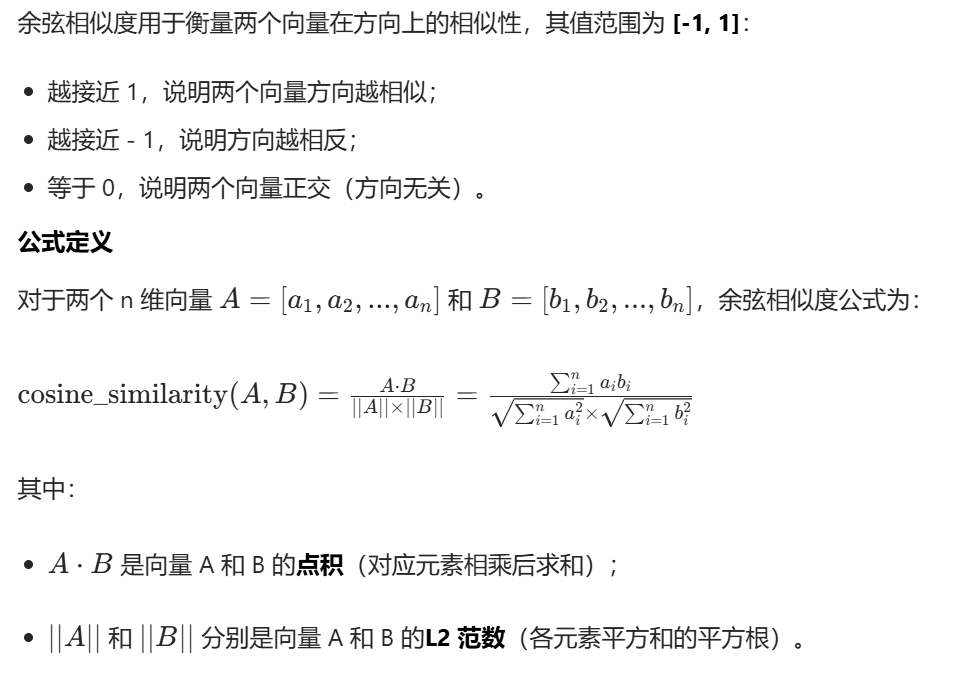

In [ ]:
# 计算点积
dot_product = np.dot(vec1, vec2)

# 计算L2范数
norm_vec1 = np.linalg.norm(vec1)
norm_vec2 = np.linalg.norm(vec2)

similarity = dot_product / (norm_vec1 * norm_vec2)

In [ ]:
print(similarity)

In [ ]:
norms = np.linalg.norm(maxtrix, axis=1)
matrix_vec_doct = np.dot(maxtrix, vec1)

In [ ]:
similarities = matrix_vec_doct/norms

## 使用cosine_similarity计算余弦相似度
**from sklearn.metrics.pairwise import cosine_similarity**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

vec1 = vec1.reshape(1,-1)
vec2 = vec2.reshape(1,-1)

In [ ]:
vec1.shape

In [ ]:
cosine_similarity(vec1,vec2)

**计算文本相似度**

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 定义文档语料库（与之前相同）
corpus = ['This is the a document for financial news',
          'This document is the document for sports news',
          'And this is the one for entertainment news',
          'Is this the first document for robot news']

# 创建并拟合TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words = "english")
tfidf_matrix = vectorizer.fit_transform(corpus) # 这里使用fit_transform对corpus做数据处理

# 定义查询
query = "robot news"

# 使用已拟合的向量化器转换查询
# 注意这里只使用transform而不是fit_transform，保持与训练时相同的词汇表
query_vector = vectorizer.transform([query])  # 这里仅仅使用已经拟合好的vectorizer做transform即可

# 计算查询向量与每个文档向量之间的余弦相似度
# cosine_similarity返回一个形状为(1, n_documents)的数组
similarities = cosine_similarity(query_vector, tfidf_matrix)

# 关键词提取（keyword extraction）

The task of a keyword extraction application is to automatically identify in a text a set of terms that best
describe the document.
* TF-IDF
* text rank

## 使用TF-IDF提取关键词

jiaba.analyse.extract_tags() 可以使用默认的TF-IDF模型对文档进行分析。 参数withWeight设置为True时可以显示词的权重,topK设置显示的词的个数。

In [ ]:
with open("sse_comments.txt","r", encoding = "utf-8") as f:
    t = f.readlines()

text = [c[20:]for c in t]

text = " ".join(text) 

In [ ]:
import jieba.analyse

key_words=jieba.analyse.extract_tags(text,topK=10,withWeight=True)
print(key_words)

## 请提取negative_comments.txt和positive_comments.tx的关键词

In [41]:
# 使用jieba.analyse.extract_tags提取negative_comments评论关键词
with open("negative_comments.txt","r", encoding = "utf-8") as f:
    t = f.read()

key_words=jieba.analyse.extract_tags(t,topK=10,withWeight=True)
print(key_words)

[('垃圾', 0.28735295363497876), ('光线', 0.20653359021835574), ('传媒', 0.13346615422663563), ('垃圾股', 0.07033543926266805), ('明天', 0.04793821870013788), ('尼玛', 0.0460140486394117), ('真是', 0.04500723621213375), ('猫眼', 0.04300931364698379), ('出货', 0.042487579548293686), ('主力', 0.04082592787388716)]


## 使用text rank提取关键词

https://xang1234.github.io/textrank/

<img src="../img/text_rank.png" align='left' height="400" width="500"/>

- [PageRank算法及其核心公式讲解](https://ai4science.feishu.cn/wiki/ThJAw8MeoibaO9k9CPBcXInUnwc)

- [PageRank算法代码](page_rank.ipynb)

a sample of text:

Compatibility of systems of linear constraints over the set of natural numbers. Criteria of compatibility of a system of linear Diophantine equations, strict inequations, and nonstrict inequations are considered. Upper bounds for components of a minimal set of solutions and algorithms of construction of minimal generating sets of solutions for all types of systems are given. These criteria and the corresponding algorithms for constructing a minimal supporting set of solutions can be used in solving all the considered types systems and systems of mixed types.

what are the keywords?

<img src="../img/text_graph.png" align='left' height="400" width="500"/>

steps to extact the keywords

- step 1: Tokenize and annotate with Part of Speech (PoS). Only consider single words. No n-grams used, multi-words are reconstructed later.
- step 2: Use syntactic filter on all the lexical units (e.g. all words, nouns and verbs only).
- step 3: Create and edge if lexical units co-occur within a window of N words to obtain an unweighted undirected graph.
- step 4: Run the text rank algorithm to rank the words.
- step 5: We take the top lexical words.
- step 6: Adjacent keywords are collapsed into a multi-word keyword.

text rank algorithm

* Starting from arbitrary values assigned to each node in the graph, the computation iterates until convergence below a given threshold is achieved. 

* After running the algorithm, a score is associated with each vertex, which represents the “importance” of the vertex within the graph. 

* Notice that the final values obtained after TextRank runs to completion are not affected by the choice of the initial value, only the number of iterations to convergence may be different.

In [39]:
import jieba.analyse

with open("negative_comments.txt", "r", encoding="utf-8") as f:
    negative_text = f.read()

In [40]:
key_words=jieba.analyse.textrank(negative_text,topK=10, withWeight=True)
key_words

[('垃圾', 1.0),
 ('光线', 0.9408021365166527),
 ('传媒', 0.696529830912739),
 ('垃圾股', 0.17822755418420938),
 ('主力', 0.17654387734461058),
 ('没有', 0.1747823281031209),
 ('猫眼', 0.16731413568197825),
 ('大盘', 0.15849082520880545),
 ('出货', 0.15794438553497478),
 ('北京', 0.1374971461108849)]

# 课后学习安排（2025.10.30-2025.11.12）
- 实验作业
- ollama下载
- 观看视频：梁文锋以及Deepseek

## 实验作业
- 工作描述与个人简历相似度计算

## 下载并安装ollama
- https://ollama.com/

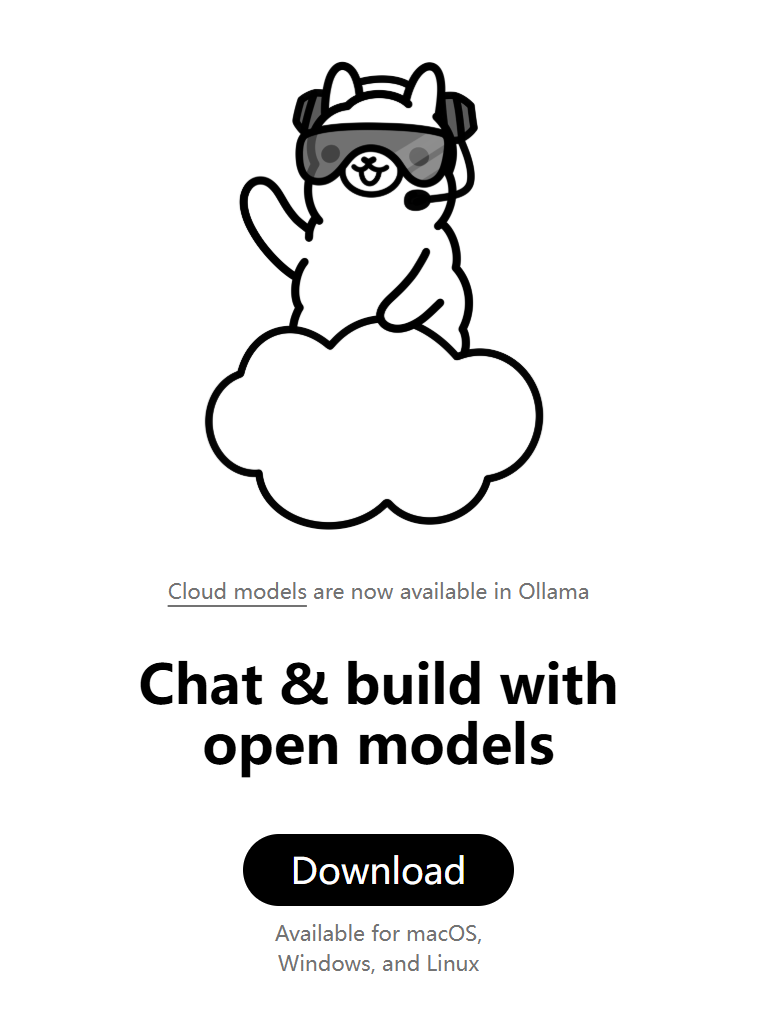

## 观看视频
- [【中英双语】DeepSeek背后的男人：梁文峰](https://www.bilibili.com/video/BV11HFieeEbU/?spm_id_from=333.337.search-card.all.click&vd_source=2656ca32dc2ca30e9c322776a5da262b)
- [DeepSeek创始人「梁文锋」发展史](https://search.bilibili.com/all?keyword=%E6%A2%81%E6%96%87%E9%94%8B&from_source=webtop_search&spm_id_from=333.788&search_source=3)

# 运动会停课安排
- 运动会停课一次（本课程的11月6日）
- 祝大家运动会取得好成绩，身体棒棒！

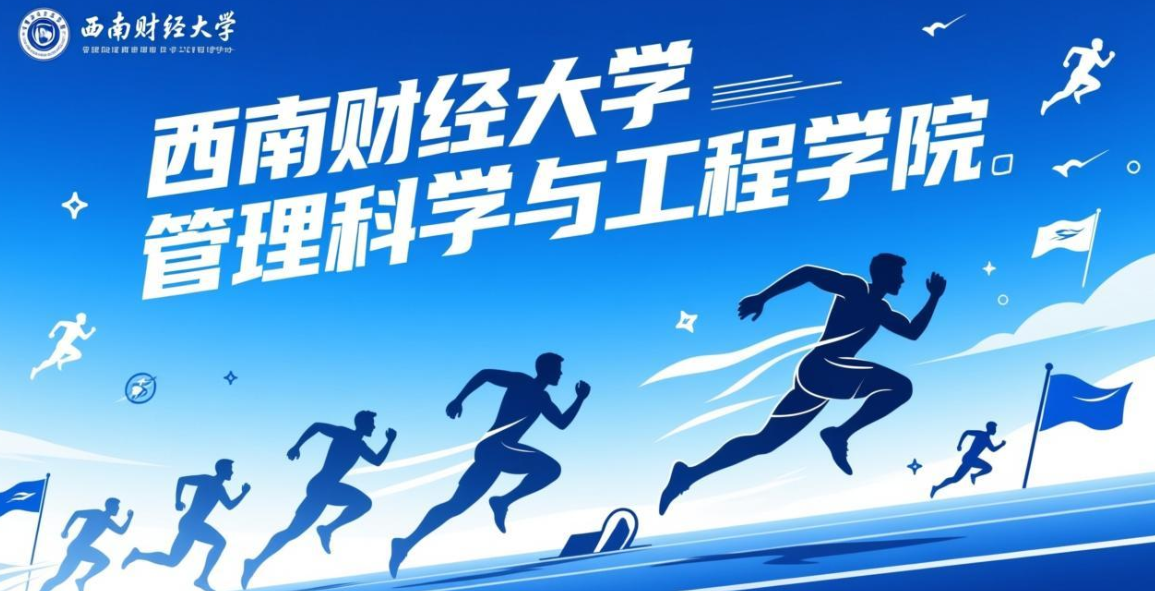